# Task-aligned state space: *where* vs *whether* — v8

Instead of plotting trajectories in **neural activity space** (hidden unit 1 vs 2, or PC1 vs PC2), this
notebook plots them in a **task-aligned space**: one axis for *where* (left versus right) and one for
*whether* (detection versus no detection).

**Why.** Hidden-unit axes and PCA frames are defined by the network, not by the task, so they differ between
seeds and between model sizes and are only defined up to rotation and reflection, which is why the earlier
cross-seed overlays were not interpretable. A decoder axis means the same thing in every network: it is the
direction along which the network's own population state carries the left/right decision, or the detection
decision. Networks **of any size**, and in principle recorded neural activity, can therefore be plotted in
the same space and compared directly.

**Method:**

1. Take a trained network and run the full test set, recording hidden states: trials x time x neurons.
2. Fit a linear (logistic) decoder predicting the **left/right** label from the hidden state, **on
   localisation trials only**.
3. Fit a second decoder predicting the **detection/no-detection** label, **on detection trials only**.
4. Take the weight vectors `w_where` and `w_whether`.
5. Project every hidden state onto both: `z_where(t) = X(t) @ w_where`, `z_whether(t) = X(t) @ w_whether`.
6. Redraw the earlier figures in this `z_where` vs `z_whether` plane.

Requires `scikit-learn`. Loads `./generated_trials_v8`.

## 1. Setup

In [2]:
import math, time
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from pathlib import Path

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cpu")
DATA_DIR = Path("./generated_trials_v8"); OUT_DIR = Path("./task_space_v8"); OUT_DIR.mkdir(exist_ok=True)
T_ON, T_OFF = 10, 20
CLASS_NAMES  = ["no det (0)", "det (1)", "right (2)", "left (3)"]
CLASS_COLORS = ["#cfcfcf", "#e0852e", "#c0392b", "#2e6ca4"]

## 2. Load data

In [3]:
def load(split):
    d = np.load(DATA_DIR / f"{split}.npz", allow_pickle=True)
    out = {"X": d["X"].astype(np.float32), "y": d["y_4class"].astype(np.int64), "types": d["types"]}
    if "aud_int" in d:                      # saved on the test split only
        out["aud_int"] = d["aud_int"].astype(np.float32)
        out["vis_int"] = d["vis_int"].astype(np.float32)
    return out

train, test = load("train"), load("test")
T = test["X"].shape[2]; N = test["X"].shape[0]
SUBTASKS = sorted(set(test["types"]))
CONFLICT = ["det_multisensory", "loc_conflict_audL_visR", "loc_conflict_audR_visL"]
NONCONF  = [s for s in SUBTASKS if s not in CONFLICT]

# trial groups used to fit the two decoders
LOC_FIT = ["loc_auditory_only_L","loc_auditory_only_R","loc_visual_only_L","loc_visual_only_R",
           "loc_multisensory_same_L","loc_multisensory_same_R"]     # left/right, no conflicts
DET_FIT = ["det_absent","det_auditory_only","det_visual_only"]      # det/no-det, det_multisensory held out
print("Train", train["X"].shape, " Test", test["X"].shape)
print("where-decoder fit on:", LOC_FIT)
print("whether-decoder fit on:", DET_FIT)

Train (4800, 4, 50)  Test (1200, 4, 50)
where-decoder fit on: ['loc_auditory_only_L', 'loc_auditory_only_R', 'loc_visual_only_L', 'loc_visual_only_R', 'loc_multisensory_same_L', 'loc_multisensory_same_R']
whether-decoder fit on: ['det_absent', 'det_auditory_only', 'det_visual_only']


## 3. Models

Standard GRU and the masked variant (self-connections only, mask applied every forward pass).

In [4]:
class StandardGRU(nn.Module):
    def __init__(self, n_in=4, hidden=2, n_out=4):
        super().__init__(); self.H = hidden
        self.gru = nn.GRU(n_in, hidden, batch_first=True); self.readout = nn.Linear(hidden, n_out)
    def forward(self, x):
        x = x.transpose(1, 2); h, _ = self.gru(x); return self.readout(h)
    def hidden_states(self, X):
        self.eval()
        with torch.no_grad(): h, _ = self.gru(torch.from_numpy(X).transpose(1, 2))
        return h.numpy()                                     # (trials, time, neurons)

class MaskedGRU(nn.Module):
    def __init__(self, n_in=4, hidden=2, n_out=4):
        super().__init__(); self.H = hidden; s = 1.0/math.sqrt(hidden)
        self.weight_ih = nn.Parameter(torch.empty(3*hidden, n_in).uniform_(-s, s))
        self.weight_hh = nn.Parameter(torch.empty(3*hidden, hidden).uniform_(-s, s))
        self.bias_ih   = nn.Parameter(torch.empty(3*hidden).uniform_(-s, s))
        self.bias_hh   = nn.Parameter(torch.empty(3*hidden).uniform_(-s, s))
        self.readout   = nn.Linear(hidden, n_out)
        self.register_buffer("mask", torch.eye(hidden).repeat(3, 1))
    def masked_hh(self): return self.weight_hh * self.mask
    def _run(self, x):
        B, Tt, _ = x.shape; H = self.H; Whh = self.masked_hh()
        Wir, Wiz, Win = self.weight_ih[:H], self.weight_ih[H:2*H], self.weight_ih[2*H:]
        Whr, Whz, Whn = Whh[:H], Whh[H:2*H], Whh[2*H:]
        bir, biz, bin_ = self.bias_ih[:H], self.bias_ih[H:2*H], self.bias_ih[2*H:]
        bhr, bhz, bhn = self.bias_hh[:H], self.bias_hh[H:2*H], self.bias_hh[2*H:]
        h = x.new_zeros(B, H); hs = []
        for t in range(Tt):
            xt = x[:, t, :]
            r = torch.sigmoid(xt @ Wir.T + bir + h @ Whr.T + bhr)
            z = torch.sigmoid(xt @ Wiz.T + biz + h @ Whz.T + bhz)
            n = torch.tanh(xt @ Win.T + bin_ + r * (h @ Whn.T + bhn))
            h = (1 - z) * n + z * h; hs.append(h)
        return torch.stack(hs, 1)
    def forward(self, x): return self.readout(self._run(x.transpose(1, 2)))
    def hidden_states(self, X):
        self.eval()
        with torch.no_grad(): h = self._run(torch.from_numpy(X).transpose(1, 2))
        return h.numpy()

## 4. Configuration

In [5]:
HIDDEN = 2
MASKED = True            # True = self-connections only, False = standard GRU
SEEDS  = [0, 1, 2, 3, 4]
N_EPOCHS = 50; LR = 1e-3; BATCH = 64

# Which timesteps to fit the decoders on. Before the stimulus the input is pure noise, so those
# timesteps carry no label information and only add noise to the fit; we therefore fit from stimulus
# onset onwards by default. Projection is still applied to every timestep.
FIT_FROM = T_ON          # set to 0 to fit on the whole trial, or T_OFF for post-stimulus only
print("HIDDEN=%d MASKED=%s seeds=%s fitting decoders from t=%d" % (HIDDEN, MASKED, SEEDS, FIT_FROM))

HIDDEN=2 MASKED=True seeds=[0, 1, 2, 3, 4] fitting decoders from t=10


## 5. Train

In [6]:
def make_model(seed, hidden=None):
    hidden = HIDDEN if hidden is None else hidden
    torch.manual_seed(seed); np.random.seed(seed)
    return (MaskedGRU if MASKED else StandardGRU)(4, hidden, 4).to(device)

def train_model(seed, hidden=None):
    model = make_model(seed, hidden)
    loader = DataLoader(TensorDataset(torch.from_numpy(train["X"]), torch.from_numpy(train["y"])),
                        batch_size=BATCH, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=LR); loss_fn = nn.CrossEntropyLoss()
    for _ in range(N_EPOCHS):
        model.train()
        for Xb, yb in loader:
            lo = model(Xb); B, Tt, C = lo.shape
            loss = loss_fn(lo.reshape(B*Tt, C), yb.unsqueeze(1).expand(B, Tt).reshape(B*Tt))
            opt.zero_grad(); loss.backward(); opt.step()
    model.eval(); return model

def evaluate(model):
    model.eval()
    with torch.no_grad(): pred = model(torch.from_numpy(test["X"]))[:, -1, :].argmax(-1).numpy()
    accs = {s: float((pred[test["types"]==s]==test["y"][test["types"]==s]).mean()) for s in SUBTASKS}
    return pred, accs, float(np.mean([accs[s] for s in NONCONF]))

models = {}; t0 = time.time()
for s in SEEDS:
    models[s] = train_model(s)
    _, _, nc = evaluate(models[s]); print("seed %d  non-conflict %.3f" % (s, nc))
print("trained in %.1f min" % ((time.time()-t0)/60))

seed 0  non-conflict 1.000
seed 1  non-conflict 0.733
seed 2  non-conflict 0.668
seed 3  non-conflict 0.999
seed 4  non-conflict 0.998
trained in 10.3 min


## 6. Fitting the task-aligned axes

Three points of care, each of which matters for whether the resulting space is interpretable.

**Conflict trials are excluded from the fits.** The *where* decoder sees only non-conflict localisation
trials and the *whether* decoder only the trained detection trials, with `det_multisensory` held out. The
conflicts and the held-out condition are therefore projected **out of sample**, so where they land is a
genuine test rather than something the axes were fit to reproduce.

**The sign of each axis is pinned explicitly.** Logistic regression's coefficient sign depends on the
internal class ordering, so without this the axes would flip arbitrarily between seeds and the cross-seed
comparison, which is the whole point of the exercise, would be meaningless. We force positive `z_where` to
mean *right* and positive `z_whether` to mean *detection*.

**Weights are unit-normalised**, so the projection is a distance along a direction rather than an
arbitrarily scaled score, and magnitudes are comparable between networks.

In [7]:
def fit_task_axes(model, verbose=True):
    """Fit where/whether decoders on a trained model. Returns axes, thresholds and diagnostics."""
    Hs = model.hidden_states(test["X"])                     # (trials, time, neurons)
    tt = np.arange(T) >= FIT_FROM                           # timesteps used for fitting
    ty = test["types"]; y4 = test["y"]

    def build(mask_trials, pos_label):
        idx = np.where(mask_trials)[0]
        Xf = Hs[idx][:, tt, :].reshape(-1, Hs.shape[2])     # (trials*time, neurons)
        yf = np.repeat((y4[idx] == pos_label).astype(int), tt.sum())
        return Xf, yf

    # where: right (label 2) vs left (label 3), localisation non-conflict trials only
    Xw, yw = build(np.isin(ty, LOC_FIT), 2)
    # whether: detection (label 1) vs no detection (label 0), detection trials only
    Xd, yd = build(np.isin(ty, DET_FIT), 1)

    where_dec   = LogisticRegression(max_iter=2000).fit(Xw, yw)
    whether_dec = LogisticRegression(max_iter=2000).fit(Xd, yd)

    w_where   = where_dec.coef_[0].astype(np.float64)
    w_whether = whether_dec.coef_[0].astype(np.float64)
    b_where, b_whether = float(where_dec.intercept_[0]), float(whether_dec.intercept_[0])

    # pin sign: +z_where = right, +z_whether = detection
    if (Xw[yw == 1] @ w_where).mean() < (Xw[yw == 0] @ w_where).mean():
        w_where, b_where = -w_where, -b_where
    if (Xd[yd == 1] @ w_whether).mean() < (Xd[yd == 0] @ w_whether).mean():
        w_whether, b_whether = -w_whether, -b_whether

    # unit-normalise (carry the threshold with the same scaling)
    nw, nd = np.linalg.norm(w_where), np.linalg.norm(w_whether)
    w_where, b_where = w_where/nw, b_where/nw
    w_whether, b_whether = w_whether/nd, b_whether/nd

    acc_w = cross_val_score(LogisticRegression(max_iter=2000), Xw, yw, cv=3).mean()
    acc_d = cross_val_score(LogisticRegression(max_iter=2000), Xd, yd, cv=3).mean()
    cosang = float(w_where @ w_whether)
    angle  = float(np.degrees(np.arccos(np.clip(abs(cosang), 0, 1))))
    if verbose:
        print("  decoder accuracy (3-fold CV):  where %.3f   whether %.3f" % (acc_w, acc_d))
        print("  angle between axes: %.1f deg  (90 = orthogonal coding)" % angle)
    return dict(w_where=w_where, w_whether=w_whether, b_where=b_where, b_whether=b_whether,
                acc_where=acc_w, acc_whether=acc_d, angle=angle)

def project(model, axes, X=None):
    """Project hidden states into (z_where, z_whether). Returns (trials, time, 2)."""
    Hs = model.hidden_states(test["X"] if X is None else X)
    zw = Hs @ axes["w_where"]; zd = Hs @ axes["w_whether"]
    return np.stack([zw, zd], -1)

axes_by_seed = {}
for s in SEEDS:
    print("seed %d:" % s); axes_by_seed[s] = fit_task_axes(models[s])

seed 0:
  decoder accuracy (3-fold CV):  where 1.000   whether 1.000
  angle between axes: 82.4 deg  (90 = orthogonal coding)
seed 1:
  decoder accuracy (3-fold CV):  where 1.000   whether 0.999
  angle between axes: 62.5 deg  (90 = orthogonal coding)
seed 2:
  decoder accuracy (3-fold CV):  where 0.999   whether 1.000
  angle between axes: 29.5 deg  (90 = orthogonal coding)
seed 3:
  decoder accuracy (3-fold CV):  where 1.000   whether 1.000
  angle between axes: 84.8 deg  (90 = orthogonal coding)
seed 4:
  decoder accuracy (3-fold CV):  where 1.000   whether 0.999
  angle between axes: 7.3 deg  (90 = orthogonal coding)


## 7. Plot helpers

The decoder thresholds give a natural crosshair: `z_where = -b_where` separates left from right and
`z_whether = -b_whether` separates no detection from detection. The four quadrants they cut out **are**
the four task conditions, which is a far more interpretable backdrop than the readout's argmax regions in
an arbitrary neural basis.

In [8]:
def subtask_style(s):
    if s == "det_multisensory":   return {"color": "#8c3b00", "ls": "--", "lw": 2.2}
    if s.startswith("det"):       return {"color": "#e0852e", "ls": "-",  "lw": 2.0}
    if "conflict" in s:           return {"color": "#12355b", "ls": "--", "lw": 2.2}
    return {"color": "#5b9bd5", "ls": "-", "lw": 2.0}

def draw_frame(ax, axes, Z, label_quadrants=True):
    xw, yd = -axes["b_where"], -axes["b_whether"]
    pad = 0.15*max(Z[:,:,0].ptp(), Z[:,:,1].ptp())
    x0, x1 = Z[:,:,0].min()-pad, Z[:,:,0].max()+pad
    y0, y1 = Z[:,:,1].min()-pad, Z[:,:,1].max()+pad
    ax.axvline(xw, color="0.6", lw=1.0, ls=":"); ax.axhline(yd, color="0.6", lw=1.0, ls=":")
    if label_quadrants:
        for (xx, yy, txt, col) in [
            (x0+(xw-x0)/2, yd+(y1-yd)/2, "left + det",   "#2e6ca4"),
            (xw+(x1-xw)/2, yd+(y1-yd)/2, "right + det",  "#c0392b"),
            (x0+(xw-x0)/2, y0+(yd-y0)/2, "left, no det", "#2e6ca4"),
            (xw+(x1-xw)/2, y0+(yd-y0)/2, "right, no det","#c0392b")]:
            ax.text(xx, yy, txt, ha="center", va="center", fontsize=8, color=col, alpha=0.55, style="italic")
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
    ax.set_xlabel("z$_{where}$   (left  \u2190  \u2192  right)")
    ax.set_ylabel("z$_{whether}$   (no det  \u2193  \u2191  det)")

## Figure 1 — average trajectory per subtask, in task space

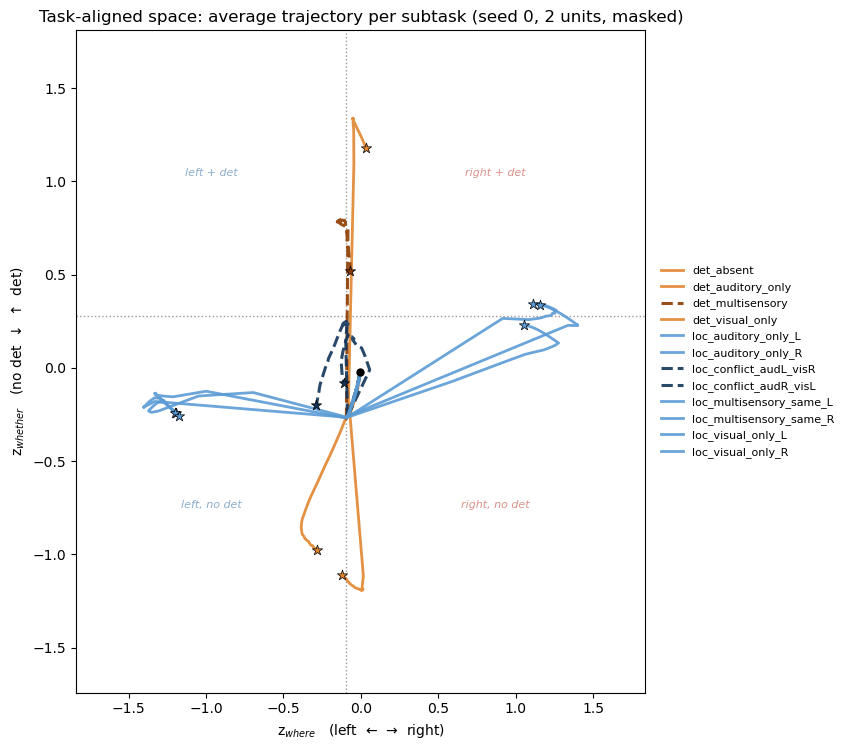

In [9]:
DISPLAY_SEED = SEEDS[0]
model = models[DISPLAY_SEED]; axes = axes_by_seed[DISPLAY_SEED]
Z = project(model, axes)

fig, ax = plt.subplots(figsize=(8.6, 7.6))
draw_frame(ax, axes, Z)
for sub in SUBTASKS:
    idx = np.where(test["types"] == sub)[0]
    tr = Z[idx].mean(0); st = subtask_style(sub)
    ax.plot(tr[:,0], tr[:,1], color=st["color"], ls=st["ls"], lw=st["lw"], alpha=0.9, label=sub)
    ax.scatter(*tr[-1], color=st["color"], s=60, marker="*", edgecolor="k", lw=0.5, zorder=6)
ax.scatter(*Z[:,0,:].mean(0), color="k", s=25, zorder=7)
ax.set_title("Task-aligned space: average trajectory per subtask (seed %d, %d units%s)"
             % (DISPLAY_SEED, HIDDEN, ", masked" if MASKED else ""))
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8, frameon=False)
plt.tight_layout(); plt.savefig(OUT_DIR / "taskspace_fig1_subtasks.png", dpi=150, bbox_inches="tight"); plt.show()

## Figure 2 — conflict trials, split by the answer the network gave

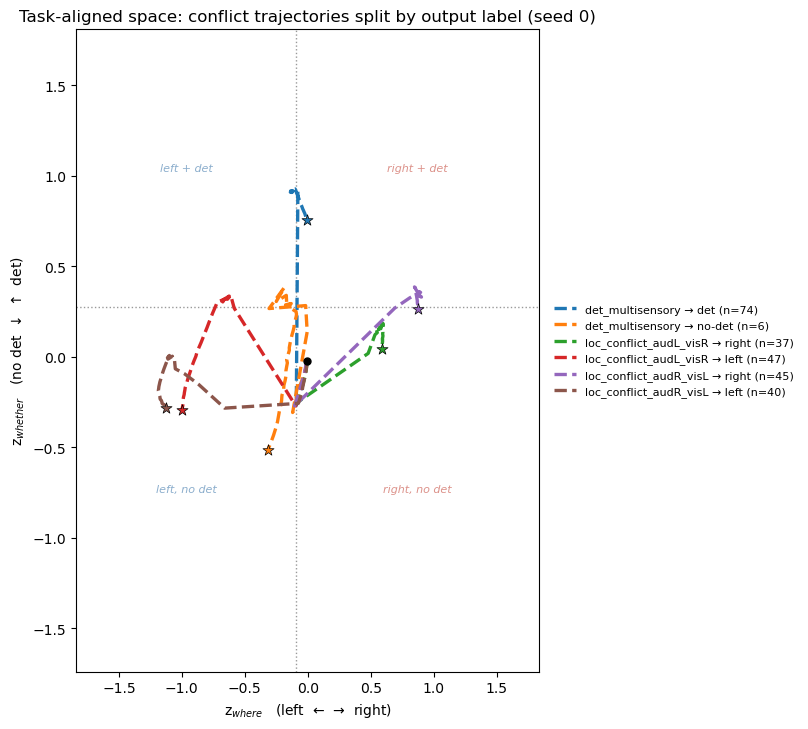

In [10]:
pred, accs, _ = evaluate(model)
fig, ax = plt.subplots(figsize=(8.2, 7.4))
draw_frame(ax, axes, Z)
cols = plt.cm.tab10(np.linspace(0, 1, 10)); ci = 0
for sub in CONFLICT:
    labs = [("det", 1), ("no-det", 0)] if sub == "det_multisensory" else [("right", 2), ("left", 3)]
    for nm, lb in labs:
        idx = np.where((test["types"] == sub) & (pred == lb))[0]
        if len(idx) == 0: continue
        tr = Z[idx].mean(0); c = cols[ci % 10]; ci += 1
        ax.plot(tr[:,0], tr[:,1], color=c, lw=2.4, ls="--", label="%s \u2192 %s (n=%d)" % (sub, nm, len(idx)))
        ax.scatter(*tr[-1], color=c, s=70, marker="*", edgecolor="k", lw=0.5, zorder=6)
ax.scatter(*Z[:,0,:].mean(0), color="k", s=25, zorder=7)
ax.set_title("Task-aligned space: conflict trajectories split by output label (seed %d)" % DISPLAY_SEED)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8, frameon=False)
plt.tight_layout(); plt.savefig(OUT_DIR / "taskspace_fig2_conflicts.png", dpi=150, bbox_inches="tight"); plt.show()

## Figure 3 — conflicts by signed stimulus strength, in task space

Binned by the **signed** intensity gap (negative means the left cue was stronger, positive the right), so
that left-going and right-going trials of the same magnitude do not cancel when averaged. In this space
the prediction is clean and directly readable: reliability-weighting should show up as the endpoints
sliding along the `z_where` axis as the gap grows, while `z_whether` stays put, because the strength of
the conflict says nothing about whether something was detected.

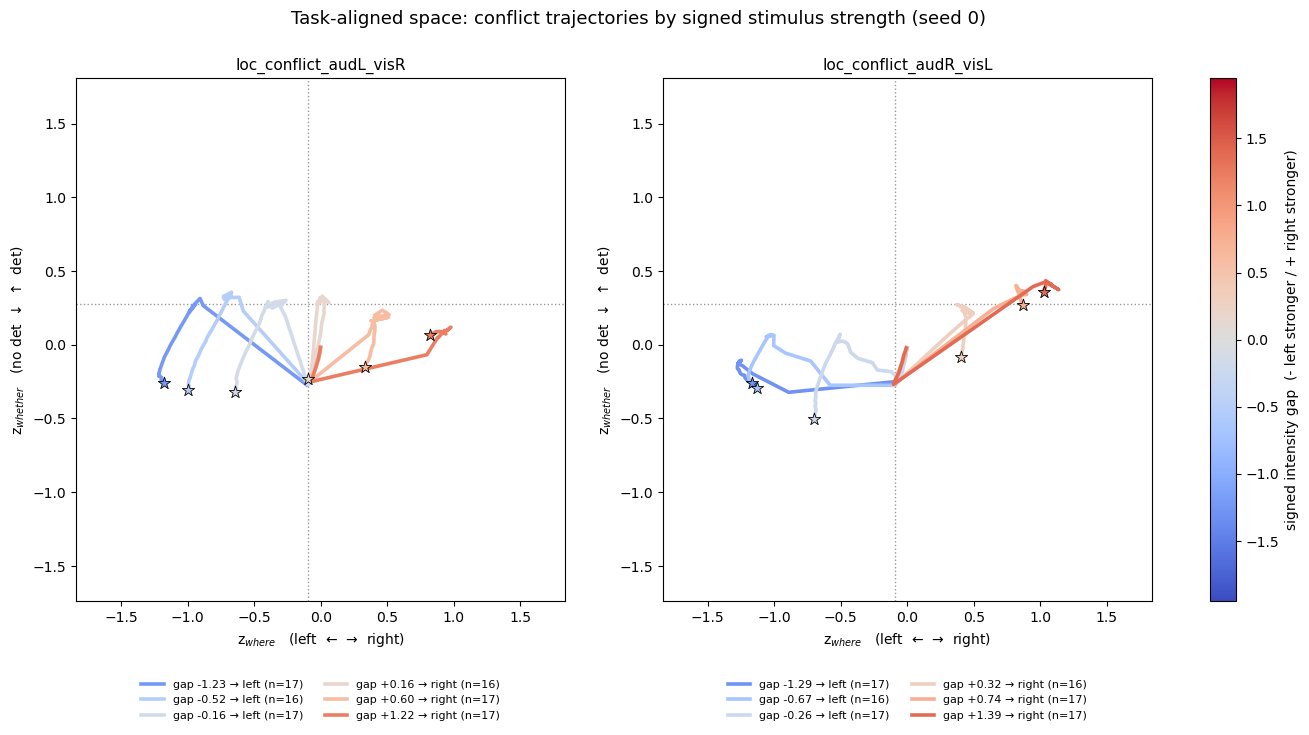

In [11]:
N_BINS = 6
LOC_CONF = ["loc_conflict_audL_visR", "loc_conflict_audR_visL"]
cmap = plt.cm.coolwarm
allg = np.abs(test["aud_int"][np.isin(test["types"], LOC_CONF)] - test["vis_int"][np.isin(test["types"], LOC_CONF)])
vmax = float(np.nanmax(allg))

fig, axs = plt.subplots(1, 2, figsize=(15, 6.8))
for ax, ctype in zip(axs, LOC_CONF):
    idx = np.where(test["types"] == ctype)[0]
    gap = np.abs(test["aud_int"][idx] - test["vis_int"][idx])
    signed = np.where(test["y"][idx] == 2, gap, -gap)         # + = right cue stronger
    edges = np.quantile(signed, np.linspace(0, 1, N_BINS+1)); edges[-1] += 1e-9
    b = np.clip(np.digitize(signed, edges[1:-1]), 0, N_BINS-1)
    draw_frame(ax, axes, Z, label_quadrants=False)
    for k in range(N_BINS):
        sel = b == k
        if sel.sum() == 0: continue
        tr = Z[idx[sel]].mean(0); g = signed[sel].mean()
        c = cmap(0.5 + 0.5*g/(vmax+1e-9))
        ax.plot(tr[:,0], tr[:,1], color=c, lw=2.6,
                label="gap %+.2f \u2192 %s (n=%d)" % (g, "right" if g > 0 else "left", sel.sum()))
        ax.scatter(*tr[-1], color=c, s=85, marker="*", edgecolor="k", lw=0.6, zorder=6)
    ax.set_title(ctype, fontsize=11)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), fontsize=8, frameon=False, ncol=2)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(-vmax, vmax)); sm.set_array([])
fig.colorbar(sm, ax=axs, label="signed intensity gap  (- left stronger / + right stronger)", fraction=0.025)
fig.suptitle("Task-aligned space: conflict trajectories by signed stimulus strength (seed %d)" % DISPLAY_SEED, fontsize=13)
plt.savefig(OUT_DIR / "taskspace_fig3_gap.png", dpi=150, bbox_inches="tight"); plt.show()

## Figure 4 — five seeds in the same space

Because the axes are defined by the **task** rather than by each network's own basis, the seeds can be shown
on comparable axes, so a difference between panels is a real difference in computation rather than a change
of coordinates. This was not possible with hidden-unit or PCA axes.

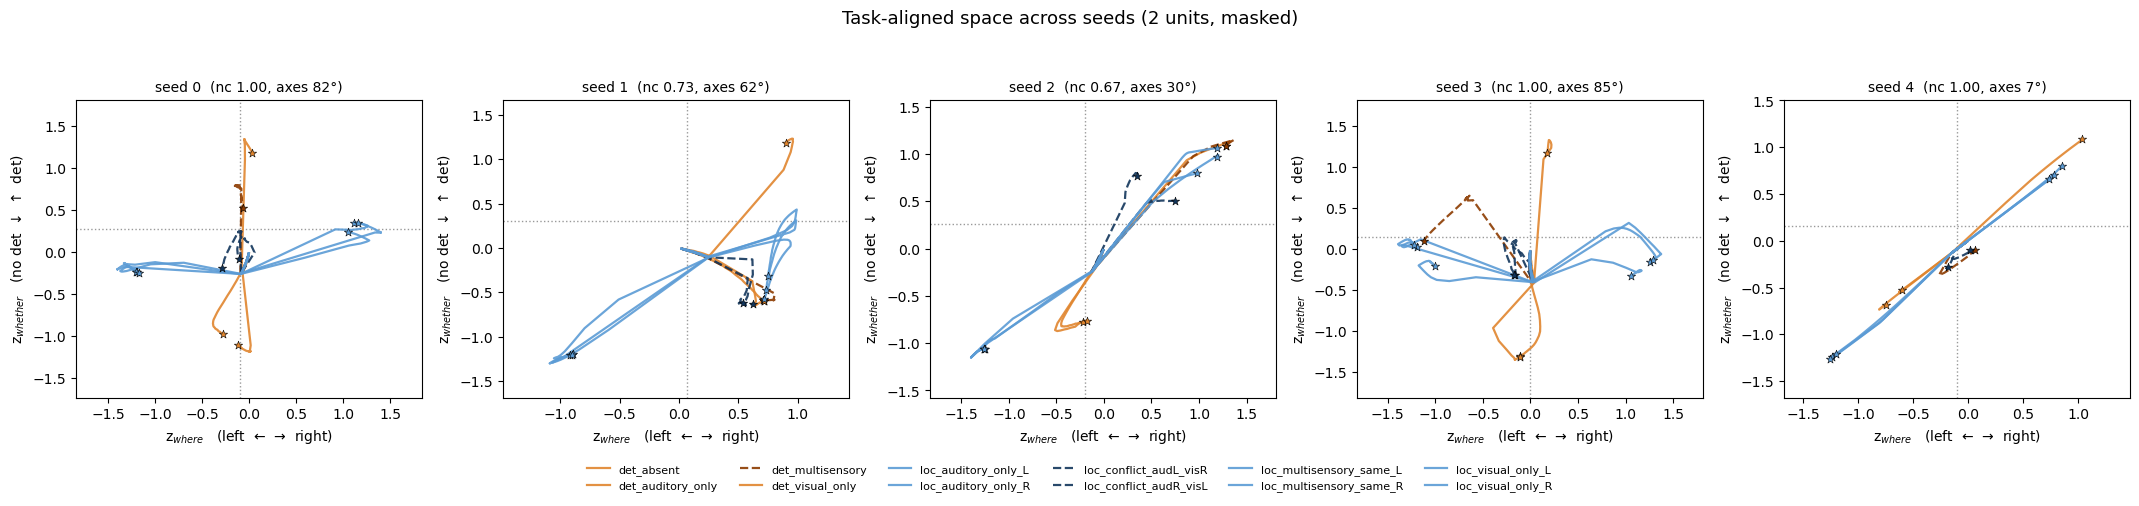

In [12]:
fig, axs = plt.subplots(1, len(SEEDS), figsize=(4.3*len(SEEDS), 4.6))
axs = np.atleast_1d(axs)
for ax, s in zip(axs, SEEDS):
    m, a = models[s], axes_by_seed[s]
    Zs = project(m, a)
    draw_frame(ax, a, Zs, label_quadrants=False)
    for sub in SUBTASKS:
        idx = np.where(test["types"] == sub)[0]
        tr = Zs[idx].mean(0); st = subtask_style(sub)
        ax.plot(tr[:,0], tr[:,1], color=st["color"], ls=st["ls"], lw=1.6, alpha=0.9,
                label=sub if s == SEEDS[0] else None)
        ax.scatter(*tr[-1], color=st["color"], s=40, marker="*", edgecolor="k", lw=0.4, zorder=6)
    _, _, nc = evaluate(m)
    ax.set_title("seed %d  (nc %.2f, axes %.0f\u00b0)" % (s, nc, a["angle"]), fontsize=10)
h, l = axs[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=6, fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.09))
fig.suptitle("Task-aligned space across seeds (%d units%s)" % (HIDDEN, ", masked" if MASKED else ""), fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(OUT_DIR / "taskspace_fig4_seeds.png", dpi=150, bbox_inches="tight"); plt.show()

## Figure 5 — different model sizes in the same space

The strongest argument for the task-aligned frame: a 2-unit, a 3-unit and a 5-unit network can be drawn on
the same axes, because *where* and *whether* mean the same thing regardless of how many neurons the network
has. The same procedure would apply to recorded neural activity.

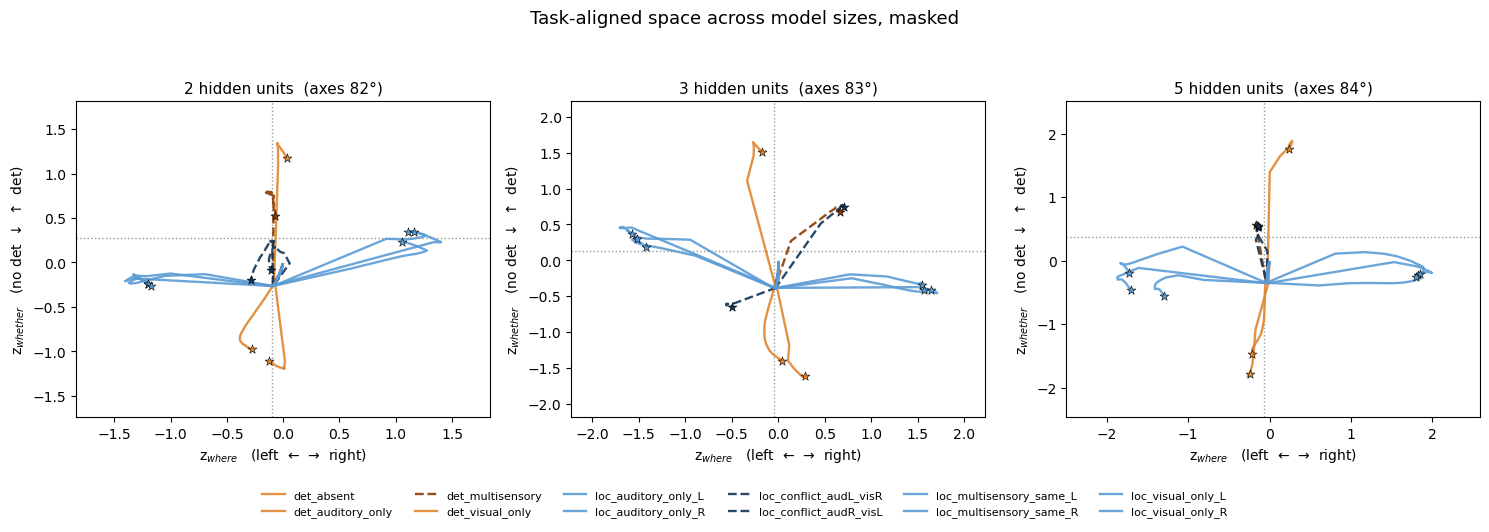

In [13]:
SIZES = [2, 3, 5]
fig, axs = plt.subplots(1, len(SIZES), figsize=(5.0*len(SIZES), 4.8))
axs = np.atleast_1d(axs)
size_models, size_axes = {}, {}
for ax, hsz in zip(axs, SIZES):
    m = train_model(SEEDS[0], hidden=hsz); size_models[hsz] = m
    a = fit_task_axes(m, verbose=False); size_axes[hsz] = a
    Zs = project(m, a)
    draw_frame(ax, a, Zs, label_quadrants=False)
    for sub in SUBTASKS:
        idx = np.where(test["types"] == sub)[0]
        tr = Zs[idx].mean(0); st = subtask_style(sub)
        ax.plot(tr[:,0], tr[:,1], color=st["color"], ls=st["ls"], lw=1.7, alpha=0.9,
                label=sub if hsz == SIZES[0] else None)
        ax.scatter(*tr[-1], color=st["color"], s=45, marker="*", edgecolor="k", lw=0.4, zorder=6)
    ax.set_title("%d hidden units  (axes %.0f\u00b0)" % (hsz, a["angle"]), fontsize=11)
h, l = axs[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=6, fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.10))
fig.suptitle("Task-aligned space across model sizes%s" % (", masked" if MASKED else ""), fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(OUT_DIR / "taskspace_fig5_sizes.png", dpi=150, bbox_inches="tight"); plt.show()

## Figure 6 — three dimensions: *where* x *whether* x time

The earlier three-dimensional plot was hard to read for a specific reason: it asked colour to carry twelve
categories at once, in a medium where occlusion and perspective already distort apparent hue and
thickness. Categorical colour reliably separates about six or seven classes in a clean two-dimensional
plot and fewer than that in three dimensions, so twelve subtasks collapsed into "orange versus blue".

The fix is to stop making colour do all of the work, and to give the third axis a meaning:

- **Axes with meaning.** `z_where` and `z_whether` are task variables, and the third axis is **time**. In a
  plot of three hidden units, none of the three axes means anything on its own, so a reader has nothing to
  anchor on. Here two of the three axes are interpretable by construction, and the third orders the
  computation, so trajectories separate as they evolve instead of tangling.
- **Small multiples.** Detection, localisation and conflict subtasks each get their own panel, on identical
  axes and with an identical camera angle, so each panel holds three or four lines rather than twelve, and
  panels remain comparable.
- **Endpoint labels instead of a legend.** Matching a legend entry to a line in three dimensions is the
  hard part, so each trajectory is labelled where it ends.
- **Wall projections.** A faint shadow of each trajectory is dropped onto the back planes, which restores
  the depth cues a static render loses and makes crossings read as crossings.

This also works for a model of any size, which the three-hidden-unit version does not.

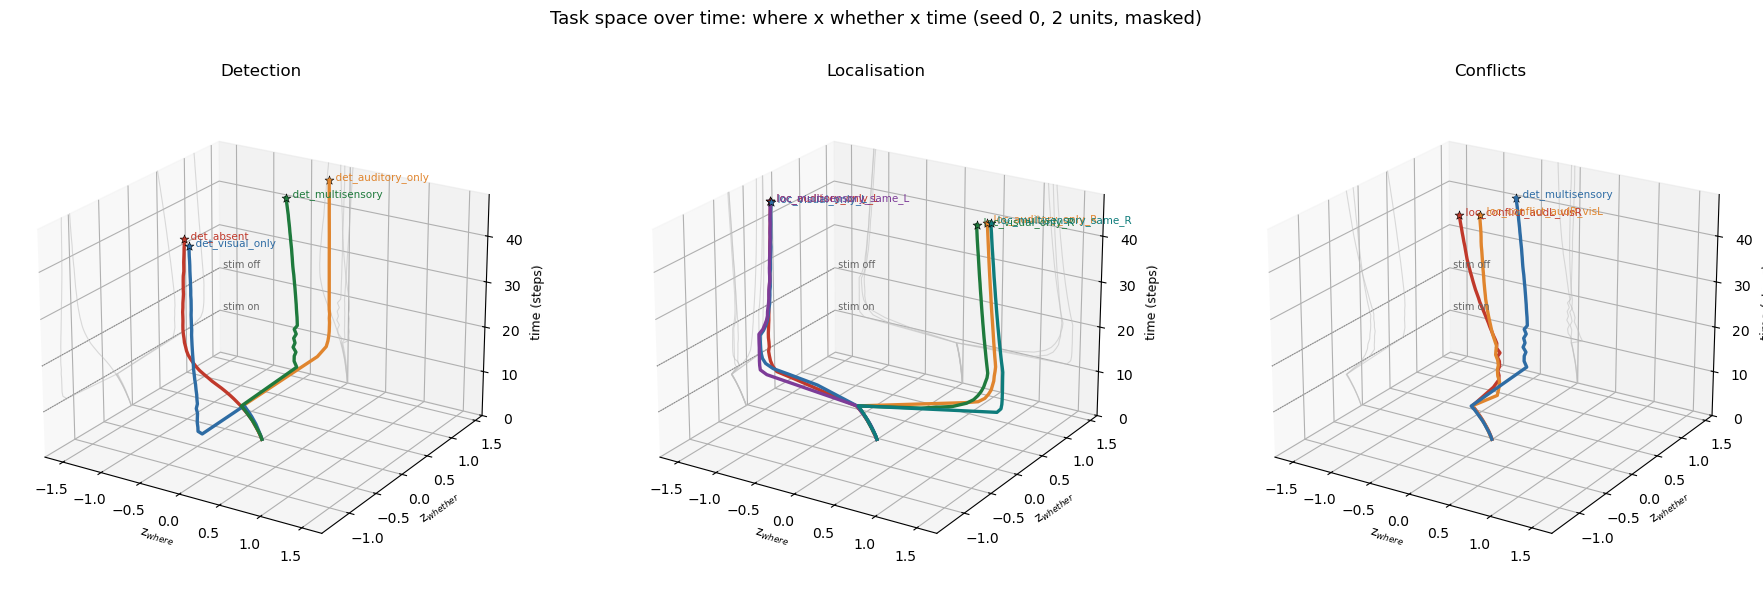

In [14]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)

# Panels: which subtasks go together. Each panel holds few enough lines for colour to work.
PANELS = [
    ("Detection", ["det_absent", "det_auditory_only", "det_visual_only", "det_multisensory"]),
    ("Localisation", ["loc_auditory_only_L", "loc_auditory_only_R", "loc_visual_only_L",
                      "loc_visual_only_R", "loc_multisensory_same_L", "loc_multisensory_same_R"]),
    ("Conflicts", ["loc_conflict_audL_visR", "loc_conflict_audR_visL", "det_multisensory"]),
]
PANEL_COLORS = ["#c0392b", "#e0852e", "#2e6ca4", "#1f7a3d", "#7d3c98", "#0e7c7b"]
ELEV, AZIM = 22, -58            # one camera angle for every panel, so they stay comparable

def _mean_traj(Z, sub):
    idx = np.where(test["types"] == sub)[0]
    return Z[idx].mean(0)

# shared limits across panels so the panels are directly comparable
_all = np.stack([_mean_traj(Z, s) for s in SUBTASKS])
XL = (_all[:, :, 0].min(), _all[:, :, 0].max())
YL = (_all[:, :, 1].min(), _all[:, :, 1].max())
pad_x = 0.12*(XL[1]-XL[0]); pad_y = 0.12*(YL[1]-YL[0])
XL = (XL[0]-pad_x, XL[1]+pad_x); YL = (YL[0]-pad_y, YL[1]+pad_y)

fig = plt.figure(figsize=(6.2*len(PANELS), 6.0))
for pi, (pname, subs) in enumerate(PANELS):
    ax = fig.add_subplot(1, len(PANELS), pi+1, projection="3d")
    tvec = np.arange(T+1) if Z.shape[1] == T+1 else np.arange(T)
    for k, sub in enumerate(subs):
        tr = _mean_traj(Z, sub); c = PANEL_COLORS[k % len(PANEL_COLORS)]
        # wall projections (faint shadows on the back planes) restore depth cues
        ax.plot(tr[:, 0], np.full(len(tr), YL[1]), tvec, color="0.75", lw=0.8, alpha=0.55, zorder=1)
        ax.plot(np.full(len(tr), XL[0]), tr[:, 1], tvec, color="0.75", lw=0.8, alpha=0.55, zorder=1)
        # the trajectory itself
        ax.plot(tr[:, 0], tr[:, 1], tvec, color=c, lw=2.4, zorder=3)
        ax.scatter(tr[-1, 0], tr[-1, 1], tvec[-1], color=c, s=45, marker="*",
                   edgecolor="k", linewidths=0.4, zorder=4)
        # label the endpoint directly rather than relying on a legend
        ax.text(tr[-1, 0], tr[-1, 1], tvec[-1], "  " + sub, color=c, fontsize=7.5, zorder=5)
    # mark the stimulus window on the time axis
    for tmark, lab in [(T_ON, "stim on"), (T_OFF, "stim off")]:
        ax.plot([XL[0], XL[0]], [YL[0], YL[1]], [tmark, tmark], color="0.5", lw=0.7, ls=":")
        ax.text(XL[0], YL[1], tmark, " " + lab, color="0.4", fontsize=7)
    ax.set_xlim(*XL); ax.set_ylim(*YL); ax.set_zlim(0, tvec[-1])
    ax.set_xlabel("z$_{where}$", fontsize=9, labelpad=2)
    ax.set_ylabel("z$_{whether}$", fontsize=9, labelpad=2)
    ax.set_zlabel("time (steps)", fontsize=9, labelpad=2)
    ax.view_init(elev=ELEV, azim=AZIM)
    ax.set_title(pname, fontsize=12, pad=4)
fig.suptitle("Task space over time: where x whether x time (seed %d, %d units%s)"
             % (DISPLAY_SEED, HIDDEN, ", masked" if MASKED else ""), fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(OUT_DIR / "taskspace_fig6_3d_panels.png", dpi=150, bbox_inches="tight")
plt.show()

### Figure 6b — colour by time instead of by subtask

Because each panel already tells you which subtask you are looking at, colour is free to carry something
else. Here it encodes **time**, which shows *when* the network commits to its answer, information that is
not visible at all in the earlier version. The stimulus window is the light part of each line, and the
long relaxation to the readout is the dark end.

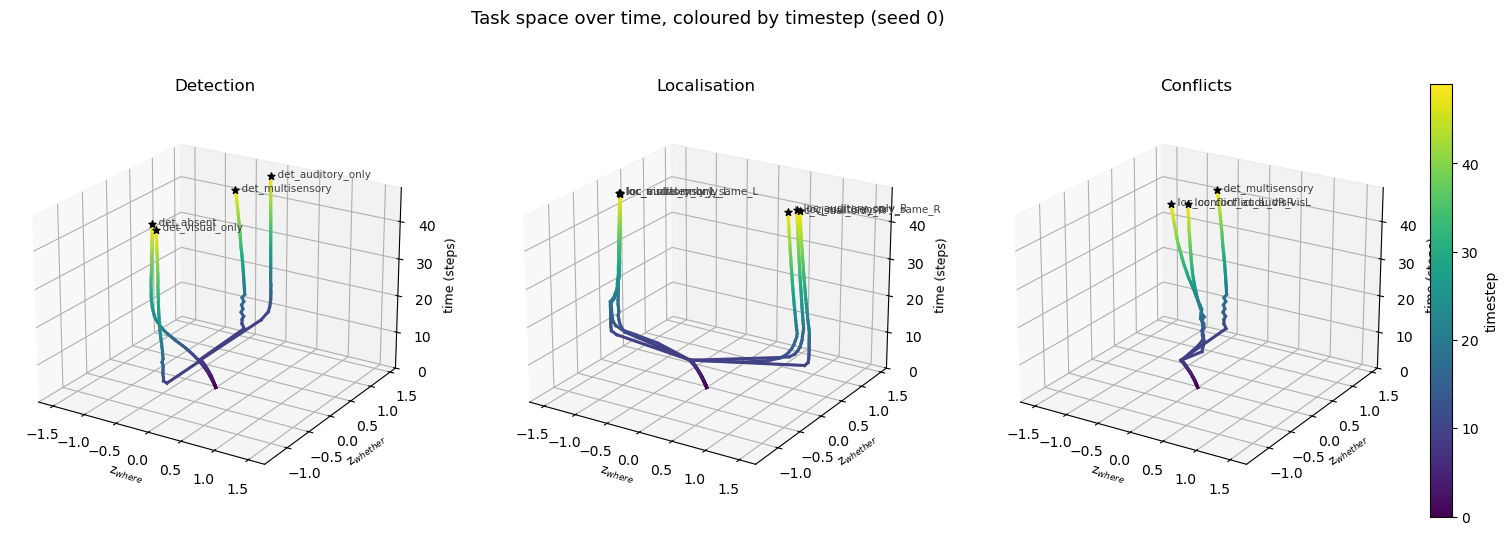

In [15]:
fig = plt.figure(figsize=(6.2*len(PANELS), 6.0))
cmap_t = plt.cm.viridis
for pi, (pname, subs) in enumerate(PANELS):
    ax = fig.add_subplot(1, len(PANELS), pi+1, projection="3d")
    tvec = np.arange(Z.shape[1])
    for sub in subs:
        tr = _mean_traj(Z, sub)
        # draw as short coloured segments so the line carries a time gradient
        for i in range(len(tr)-1):
            ax.plot(tr[i:i+2, 0], tr[i:i+2, 1], tvec[i:i+2],
                    color=cmap_t(i/(len(tr)-1)), lw=2.2)
        ax.scatter(tr[-1, 0], tr[-1, 1], tvec[-1], color="k", s=28, marker="*", zorder=5)
        ax.text(tr[-1, 0], tr[-1, 1], tvec[-1], "  " + sub, fontsize=7.5, color="0.25")
    ax.set_xlim(*XL); ax.set_ylim(*YL); ax.set_zlim(0, tvec[-1])
    ax.set_xlabel("z$_{where}$", fontsize=9, labelpad=2)
    ax.set_ylabel("z$_{whether}$", fontsize=9, labelpad=2)
    ax.set_zlabel("time (steps)", fontsize=9, labelpad=2)
    ax.view_init(elev=ELEV, azim=AZIM); ax.set_title(pname, fontsize=12, pad=4)
sm = plt.cm.ScalarMappable(cmap=cmap_t, norm=plt.Normalize(0, Z.shape[1]-1)); sm.set_array([])
fig.colorbar(sm, ax=fig.axes, label="timestep", fraction=0.015, pad=0.02)
fig.suptitle("Task space over time, coloured by timestep (seed %d)" % DISPLAY_SEED, fontsize=13)
plt.savefig(OUT_DIR / "taskspace_fig6b_3d_time.png", dpi=150, bbox_inches="tight")
plt.show()

### Figure 6c — interactive version

If `plotly` is installed this renders a rotatable plot in which **clicking a legend entry isolates that
trajectory**, which solves the crowding problem a different way: the reader removes what they do not want to
see rather than the author guessing in advance. Hovering gives the subtask name and the timestep. This is the
version for exploring; the static panels above are the ones for the report.

In [16]:
try:
    import plotly.graph_objects as go
    tvec = np.arange(Z.shape[1])
    figp = go.Figure()
    for sub in SUBTASKS:
        tr = _mean_traj(Z, sub); st = subtask_style(sub)
        figp.add_trace(go.Scatter3d(
            x=tr[:, 0], y=tr[:, 1], z=tvec, mode="lines", name=sub,
            line=dict(width=5, color=st["color"], dash="dash" if st["ls"] == "--" else "solid"),
            hovertemplate=sub + "<br>z_where %{x:.2f}<br>z_whether %{y:.2f}<br>t %{z}<extra></extra>"))
        figp.add_trace(go.Scatter3d(x=[tr[-1, 0]], y=[tr[-1, 1]], z=[tvec[-1]], mode="markers",
                                    marker=dict(size=4, color=st["color"]), showlegend=False,
                                    hoverinfo="skip"))
    figp.update_layout(
        title="Task space over time (click a legend entry to isolate a trajectory)",
        scene=dict(xaxis_title="z_where", yaxis_title="z_whether", zaxis_title="time (steps)",
                   camera=dict(eye=dict(x=1.6, y=-1.6, z=0.9))),
        width=980, height=740, legend=dict(itemsizing="constant", font=dict(size=10)))
    figp.show()
except ImportError:
    print("plotly not installed, so the interactive version was skipped.")
    print("Install with:  pip install plotly")

plotly not installed, so the interactive version was skipped.
Install with:  pip install plotly


### Figure 6d — neural space, for dimensionality only

The three-hidden-unit network drawn in its own activity space, with no projection at all. This is kept for
one narrow purpose: to show whether a three-unit network genuinely uses all three dimensions or collapses
onto a plane. It is **not** the figure to read the computation from, because none of its three axes carries
a task meaning, which is precisely the problem the task-aligned space solves. The participation ratio
printed underneath answers the dimensionality question numerically, so the plot only has to support it.

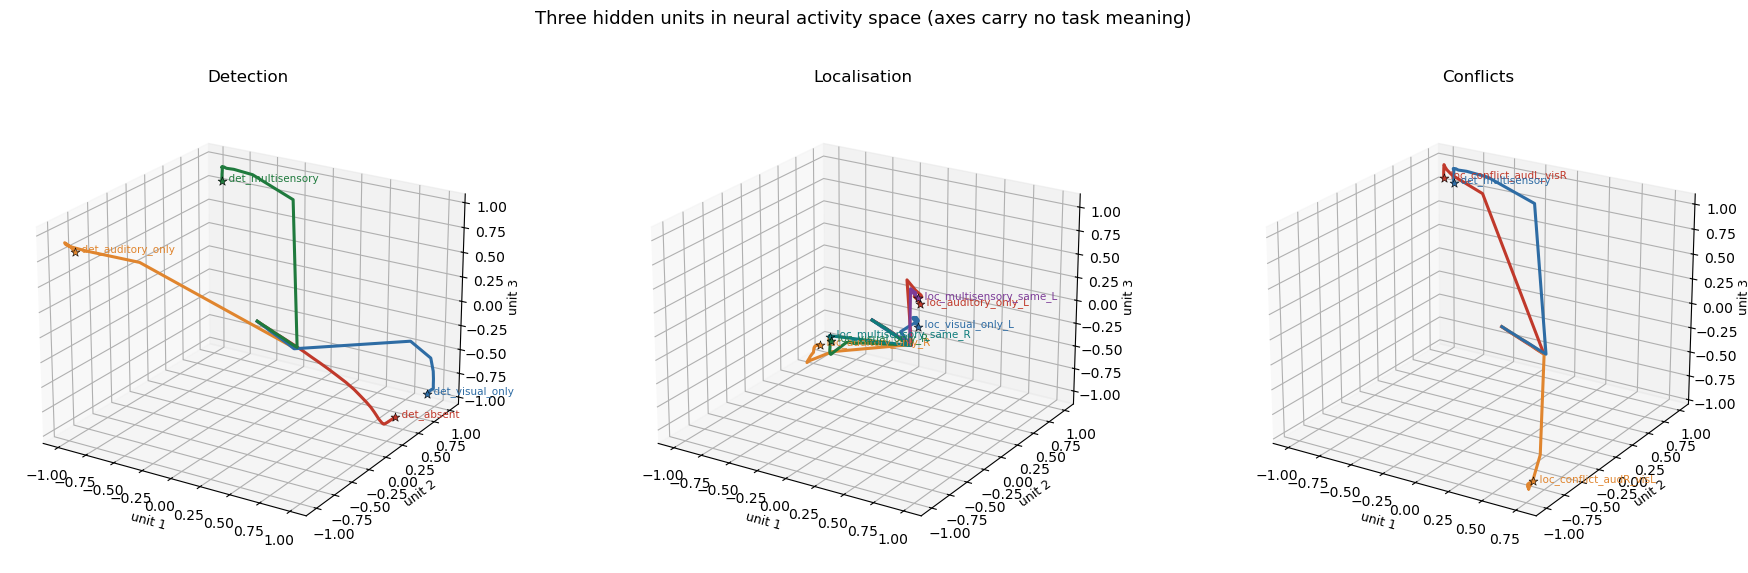

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
endpoint variance per dimension: [0.565 0.332 0.103]
participation ratio 2.27 of 3  (near 2 means the endpoints lie close to a plane)


In [17]:
m3 = train_model(SEEDS[0], hidden=3)
H3 = m3.hidden_states(test["X"])                      # (trials, time, 3)

fig = plt.figure(figsize=(6.2*len(PANELS), 5.8))
for pi, (pname, subs) in enumerate(PANELS):
    ax = fig.add_subplot(1, len(PANELS), pi+1, projection="3d")
    for k, sub in enumerate(subs):
        idx = np.where(test["types"] == sub)[0]
        tr = H3[idx].mean(0); c = PANEL_COLORS[k % len(PANEL_COLORS)]
        ax.plot(tr[:, 0], tr[:, 1], tr[:, 2], color=c, lw=2.2)
        ax.scatter(*tr[-1], color=c, s=45, marker="*", edgecolor="k", linewidths=0.4)
        ax.text(*tr[-1], "  " + sub, color=c, fontsize=7.5)
    ax.set_xlabel("unit 1", fontsize=9, labelpad=2); ax.set_ylabel("unit 2", fontsize=9, labelpad=2)
    ax.set_zlabel("unit 3", fontsize=9, labelpad=2)
    ax.view_init(elev=ELEV, azim=AZIM); ax.set_title(pname, fontsize=12, pad=4)
fig.suptitle("Three hidden units in neural activity space (axes carry no task meaning)", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(OUT_DIR / "taskspace_fig6d_neural3d.png", dpi=150, bbox_inches="tight")
plt.show()

# does it use all three dimensions, or collapse onto a plane?
E = H3[:, -1, :]
C = np.cov((E - E.mean(0)).T)
ev = np.clip(np.linalg.eigvalsh(C), 0, None)[::-1]
pr = float((ev.sum()**2)/(np.sum(ev**2) + 1e-12))
print("endpoint variance per dimension: %s" % np.round(ev/ev.sum(), 3))
print("participation ratio %.2f of 3  (near 2 means the endpoints lie close to a plane)" % pr)

## 8. Quantifying the geometry

Two numbers that replace looking at shapes, both read straight off the decoder axes.

**Angle between the axes.** 90 degrees means *where* and *whether* are encoded in orthogonal directions, so
the code is factorised and the two decisions do not interfere. A smaller angle means localisation evidence
leaks into the detection readout and vice versa. There is a reason to expect orthogonality: the two variables
are statistically independent in the task, so any overlap costs loss without buying anything.

**Alignment to the hidden-unit axes** (2-unit networks only). This measures the rotation of the solution.
0 degrees means each task is carried by its own hidden unit; 45 degrees means both units carry both tasks,
which is the "rotated cross". This is the quantity the noise hypothesis was supposed to explain.

In [18]:
def alignment_to_units(w):
    """Angle (deg) from the nearest hidden-unit axis: 0 = axis-aligned, 45 = maximally rotated (2D only)."""
    ang = np.degrees(np.arctan2(abs(w[1]), abs(w[0])))
    return float(min(ang, 90 - ang))

print(f"{'seed':>5} {'axes angle':>11} {'where acc':>10} {'whether acc':>12}"
      + (f" {'align where':>12} {'align whether':>14}" if HIDDEN == 2 else ""))
print("-" * (40 + (28 if HIDDEN == 2 else 0)))
rows = []
for s in SEEDS:
    a = axes_by_seed[s]
    line = f"{s:>5} {a['angle']:>10.1f}\u00b0 {a['acc_where']:>10.3f} {a['acc_whether']:>12.3f}"
    if HIDDEN == 2:
        aw, ad = alignment_to_units(a["w_where"]), alignment_to_units(a["w_whether"])
        line += f" {aw:>11.1f}\u00b0 {ad:>13.1f}\u00b0"
        rows.append((s, a["angle"], aw, ad))
    else:
        rows.append((s, a["angle"], np.nan, np.nan))
    print(line)
r = np.array(rows, dtype=float)
print("\nmean angle between axes: %.1f\u00b0 (sd %.1f)" % (np.nanmean(r[:,1]), np.nanstd(r[:,1])))
if HIDDEN == 2:
    print("mean alignment to hidden-unit axes: where %.1f\u00b0, whether %.1f\u00b0  (0 = one unit per task, 45 = fully shared)"
          % (np.nanmean(r[:,2]), np.nanmean(r[:,3])))

print("\nModel sizes:")
for hsz in SIZES:
    print("  %d units: axes angle %.1f\u00b0, where acc %.3f, whether acc %.3f"
          % (hsz, size_axes[hsz]["angle"], size_axes[hsz]["acc_where"], size_axes[hsz]["acc_whether"]))

 seed  axes angle  where acc  whether acc  align where  align whether
--------------------------------------------------------------------
    0       82.4°      1.000        1.000        43.5°          36.0°
    1       62.5°      1.000        0.999         5.5°          22.0°
    2       29.5°      0.999        1.000        39.6°          10.1°
    3       84.8°      1.000        1.000        37.0°          42.2°
    4        7.3°      1.000        0.999        39.6°          43.1°

mean angle between axes: 53.3° (sd 30.4)
mean alignment to hidden-unit axes: where 33.1°, whether 30.7°  (0 = one unit per task, 45 = fully shared)

Model sizes:
  2 units: axes angle 82.4°, where acc 1.000, whether acc 1.000
  3 units: axes angle 83.4°, where acc 1.000, whether acc 0.999
  5 units: axes angle 83.6°, where acc 1.000, whether acc 1.000


In [ ]:

import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_score

N_SPLITS = 3     # same fold count as the cross_val_score(..., cv=3) used above


def _build(Hs, idx, pos_label, tt):
    """Same row construction as fit_task_axes.build(), plus a trial id per row."""
    n_t = int(tt.sum())
    X = Hs[idx][:, tt, :].reshape(-1, Hs.shape[2])
    y = np.repeat((test["y"][idx] == pos_label).astype(int), n_t)
    g = np.repeat(np.arange(len(idx)), n_t)          # one group per trial
    return X, y, g


def pooled_vs_grouped(model):
    """Return dict of pooled and trial-grouped CV accuracy for both decoders."""
    Hs = model.hidden_states(test["X"])
    tt = np.arange(T) >= FIT_FROM
    ty = test["types"]

    out = {}
    for name, keep, pos in [("where", LOC_FIT, 2), ("whether", DET_FIT, 1)]:
        idx = np.where(np.isin(ty, keep))[0]
        X, y, g = _build(Hs, idx, pos, tt)
        clf = lambda: LogisticRegression(max_iter=2000)
        out[name + "_pooled"]  = cross_val_score(clf(), X, y, cv=N_SPLITS).mean()
        out[name + "_grouped"] = cross_val_score(clf(), X, y, groups=g,
                                                 cv=GroupKFold(n_splits=N_SPLITS)).mean()
        out[name + "_ntrials"] = len(idx)
    return out


arch = "masked" if MASKED else "standard"
rows = []

# --- the five seeds at the current hidden size -----------------------------
for s in sorted(models):
    r = pooled_vs_grouped(models[s])
    r.update(architecture=arch, hidden=HIDDEN, seed=s)
    rows.append(r)

# --- the size sweep (seed 0 at each size in SIZES) -------------------------
try:
    for hsz in sorted(size_models):
        if hsz == HIDDEN:
            continue                     # already covered by the seed loop above
        r = pooled_vs_grouped(size_models[hsz])
        r.update(architecture=arch, hidden=hsz, seed=SEEDS[0])
        rows.append(r)
except NameError:
    print("size_models not defined - skipping the size sweep. "
          "Run the 'Task-aligned space across model sizes' cell first if you want it.")

cols = ["architecture", "hidden", "seed",
        "where_pooled", "where_grouped", "whether_pooled", "whether_grouped",
        "where_ntrials", "whether_ntrials"]
df = pd.DataFrame(rows)[cols]
for c in cols[3:7]:
    df[c] = df[c].round(4)

pd.set_option("display.width", 200)
print("architecture = %s, decoders fitted from t=%d, %d-fold CV\n" % (arch, FIT_FROM, N_SPLITS))
print(df.to_string(index=False))

print("\n--- mean over rows ---")
print("where   pooled %.4f -> grouped %.4f  (drop %.4f)"
      % (df.where_pooled.mean(), df.where_grouped.mean(),
         df.where_pooled.mean() - df.where_grouped.mean()))
print("whether pooled %.4f -> grouped %.4f  (drop %.4f)"
      % (df.whether_pooled.mean(), df.whether_grouped.mean(),
         df.whether_pooled.mean() - df.whether_grouped.mean()))

df.to_csv(OUT_DIR / ("decoder_grouped_cv_%s.csv" % arch), index=False)
print("\nSaved", OUT_DIR / ("decoder_grouped_cv_%s.csv" % arch))


architecture = masked, decoders fitted from t=10, 3-fold CV

architecture  hidden  seed  where_pooled  where_grouped  whether_pooled  whether_grouped  where_ntrials  whether_ntrials
      masked       2     0        1.0000         1.0000          1.0000           1.0000            600              300
      masked       2     1        0.9997         0.9997          0.9989           0.9989            600              300
      masked       2     2        0.9994         0.9995          1.0000           1.0000            600              300
      masked       2     3        0.9999         0.9999          1.0000           1.0000            600              300
      masked       2     4        0.9998         0.9998          0.9987           0.9987            600              300
      masked       3     0        0.9999         1.0000          0.9995           0.9994            600              300
      masked       5     0        1.0000         1.0000          1.0000           1.0000    

## Notes

- The decoders are fit on **non-conflict trials only**, so every conflict trajectory and the held-out
  `det_multisensory` condition are projected out of sample. Where they land is therefore a result, not a
  consequence of the fit.
- Decoder accuracy is reported by cross-validation. If it is near chance the axis is not meaningful and the
  corresponding plots should not be over-interpreted.
- Axis signs are pinned so that positive means right and positive means detection in every network, which
  is what makes the cross-seed and cross-size panels comparable.
- The same procedure applies unchanged to any model size, and to recorded neural activity, which is the
  main advantage over hidden-unit or PCA axes.